# **TASK 4: SENTIMENT ANALYSIS USING NLP**

This project analyzes customer reviews and classifies them into positive, negative, or neutral sentiments using NLP techniques.

Data **Load**

In [1]:
import pandas as pd

df = pd.read_csv("Reviews.csv", nrows=5000)
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [2]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 5000 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


# **Data Preprocessing**

In [4]:
df = df[['Text', 'Score']]

In [5]:
df.columns = ['review', 'rating']

In [6]:
df.dropna(inplace=True)

In [7]:
df['review'] = df['review'].str.lower()

# **Rating-> Sentiment**

In [8]:
def get_label(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['rating'].apply(get_label)

# **NLP Sentiment**

In [9]:
!pip install textblob

In [10]:
from textblob import TextBlob

def analyze_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['polarity'] = df['review'].apply(analyze_sentiment)

# **Visualization**

# **Bar Chart**

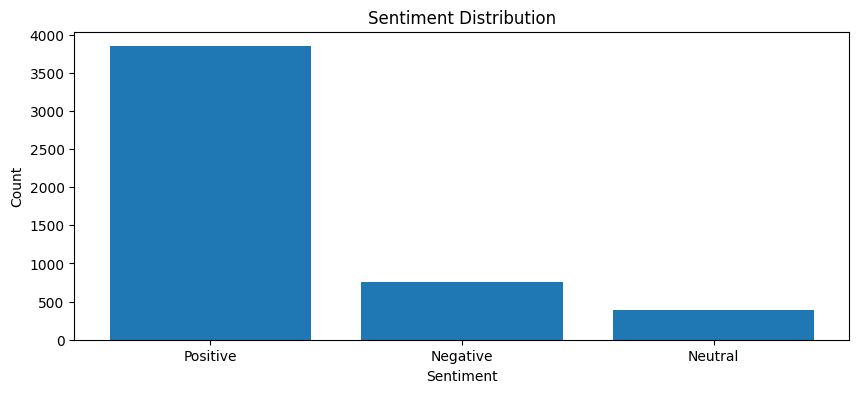

In [12]:
import matplotlib.pyplot as plt

sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(10,4))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# **Pie Chart**

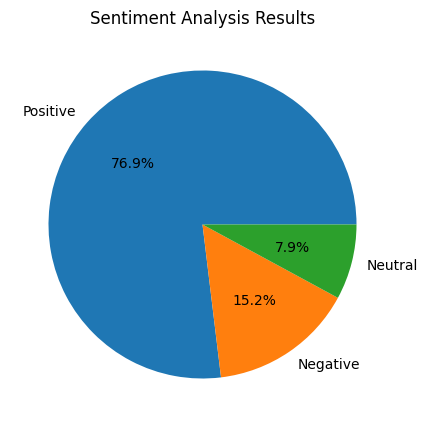

In [13]:
plt.figure(figsize=(5,5))

plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%')

plt.title("Sentiment Analysis Results")

plt.show()

In [14]:
df.groupby('Sentiment')['polarity'].mean()

,polarity
Sentiment,
Negative,0.026960
Neutral,0.160762
Positive,0.296431


# **INSIGHTS FROM SENTIMENT ANALYSIS**

1. The dataset contains a large number of customer reviews.

2. Most reviews are positive, indicating overall customer satisfaction.

3. Negative reviews highlight areas where improvements are needed.

4. Neutral reviews represent mixed opinions.

5. Sentiment analysis helps businesses understand customer feedback efficiently.